# Backtesting Results

## Imports

In [1]:
import sys
import os
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

from src.data import get_close_prices, get_market_cap, get_ohlcv, get_risk_free_daily, get_risk_free_rate, get_price_timeseries, get_sp500_prices
from src.modelling import TICKERS, TRAIN_START, TRAIN_END, TEST_START, TEST_END, INTERVAL, TICKER_NAMES, CANDIDATE_PAIRS, RISK_FREE_RATE
from src.modelling import engle_granger_test, screen_pairs, adf_test # co-integration
from src.modelling import spread_summary, compute_spread, compute_zscore, compute_rolling_half_life, compute_rolling_zscore # spread analysis
from src.modelling import compute_spread_returns, build_spread_return_matrix, historical_mean_return, ewma_return, ou_expected_return, build_ou_expected_returns, sample_covariance, shrinkage_covariance, spread_vs_traditional_estimates
from src.modelling import mean_variance_weights, minimum_variance_weights, max_sharpe_weights, efficient_frontier

# Backtest engine + config
from src.backtesting import (
    PairsBacktestEngine,
    BacktestConfig,
    BacktestResult,
)

# Performance metrics
from src.backtesting import (
    compute_ex_post_sharpe_ratio,
    compute_max_drawdown,
    compute_volatility_reduction,
)

# Benchmarks
from src.backtesting import (
    risk_free_returns, buy_and_hold_returns,
    equal_weight_pairs_returns, market_returns,
    compute_benchmark_metrics, build_all_benchmarks,
    historical_mpt_returns,
)

## Load outputs from previous notebooks

In [2]:
spread_mu      = pd.read_csv("../../data/processed/spread_mu.csv",    index_col=0).squeeze()
asset_mu       = pd.read_csv("../../data/processed/asset_mu.csv",     index_col=0).squeeze()
spread_cov     = pd.read_csv("../../data/processed/spread_cov.csv",   index_col=0)
asset_cov      = pd.read_csv("../../data/processed/asset_cov.csv",    index_col=0)
cointegrated_pairs    = pd.read_csv("../../data/processed/cointegrated_pairs.csv")
oos_log_prices_df     = pd.read_csv("../../data/processed/prices_log_oos.csv", index_col=0, parse_dates=True)
oos_raw_prices_df = pd.read_csv("../../data/processed/prices_raw_oos.csv", index_col=0, parse_dates=True)

In [3]:
print(spread_mu)
print(asset_mu)

CVX.N_vs_XOM.N   -0.039769
KO.N_vs_PEP.O     0.019327
GS.N_vs_MS.N     -0.106908
Name: ou_expected_return, dtype: float64
CVX.N    0.123651
KO.N     0.068765
GS.N     0.215655
XOM.N    0.131534
PEP.O    0.112049
MS.N     0.229549
Name: 0, dtype: float64


## Reconstruct OOS Spread REturns

In [4]:
spread_returns = build_spread_return_matrix(oos_raw_prices_df, cointegrated_pairs)

display(spread_returns)

,CVX.N_vs_XOM.N,KO.N_vs_PEP.O,GS.N_vs_MS.N
Date,,,
2024-01-03,0.013068,0.002187,0.000196
2024-01-04,-0.004738,0.002347,0.000948
2024-01-05,-0.003889,0.008292,-0.000354
2024-01-08,0.005912,0.006706,0.003945
2024-01-09,-0.016575,0.005788,-0.000756
...,...,...,...
2025-12-24,0.001129,0.003158,0.000472
2025-12-26,-0.002531,-0.003608,-0.005076
2025-12-29,-0.002046,0.002026,-0.007890


## Solve Portfolio Weights

### Obtain risk-free rate

In [5]:
rf_daily = get_risk_free_daily(start="2019-01-01", end="2023-12-31")

rf_annual_avg = (rf_daily * 252).mean()     # back to annual
rf_annual_avg = float(f"{rf_annual_avg:.1g}") # round to 1sf
print(f"Average Risk-Free rate for backtesting: {rf_annual_avg}")

[cache partial] Fetching 2019-01-01 → 2019-01-01
LSEG session opened.
[cache partial] Skipping (no trading data): LSEG returned no data for ['US3MT=RR'] (2019-01-01 to 2019-01-01)
[cache partial] Fetching 2023-12-30 → 2023-12-31
[cache partial] Skipping (no trading data): LSEG returned no data for ['US3MT=RR'] (2023-12-30 to 2023-12-31)
Average Risk-Free rate for backtesting: 0.02


## Build benchmark series

Get S&P 500 data

In [6]:
spy_prices = get_sp500_prices(TEST_START, TEST_END)

In [7]:
benchmarks = build_all_benchmarks(
    test_prices=oos_raw_prices_df,
    coint_pairs=cointegrated_pairs,
    rf_annual=rf_annual_avg,
    market_prices=spy_prices.squeeze(),
)

print(benchmarks)

{'risk_free': Date
2024-01-02    0.000079
2024-01-03    0.000079
2024-01-04    0.000079
2024-01-05    0.000079
2024-01-08    0.000079
                ...   
2025-12-24    0.000079
2025-12-26    0.000079
2025-12-29    0.000079
2025-12-30    0.000079
2025-12-31    0.000079
Name: risk_free, Length: 502, dtype: float64, 'buy_hold_pair': Date
2024-01-03    0.013734
2024-01-04   -0.009841
2024-01-05    0.000652
2024-01-08   -0.011323
2024-01-09   -0.018902
                ...   
2025-12-24   -0.000871
2025-12-26   -0.002056
2025-12-29    0.009194
2025-12-30    0.006279
2025-12-31   -0.002358
Name: buy_and_hold, Length: 501, dtype: float64, 'equal_weight_pairs': Date
2024-01-03    0.005150
2024-01-04   -0.000481
2024-01-05    0.001350
2024-01-08    0.005521
2024-01-09   -0.003848
                ...   
2025-12-24    0.001586
2025-12-26   -0.003738
2025-12-29   -0.002636
2025-12-30    0.000077
2025-12-31    0.001985
Name: equal_weight_pairs, Length: 501, dtype: float64, 'sp500': Date
2024-01-0

## Obtain two weight vectors (max sharpe weights)

In [8]:
tickers = list(dict.fromkeys(
    cointegrated_pairs['y'].tolist() + cointegrated_pairs['x'].tolist()
))

# Dummy returns DataFrame just to satisfy the function signature
# (actual mu and cov are passed explicitly, so the values don't matter)
asset_returns_oos = oos_raw_prices_df[tickers].pct_change().dropna()

display(asset_returns_oos)

,CVX.N,KO.N,GS.N,XOM.N,PEP.O,MS.N
Date,,,,,,
2024-01-03,0.019066,0.002340,-0.016765,0.008402,0.000231,-0.021193
2024-01-04,-0.010963,-0.003336,0.003038,-0.008719,-0.008557,0.002611
2024-01-05,-0.001726,-0.001506,0.009113,0.003030,-0.014755,0.011829
2024-01-08,-0.005984,0.007374,0.006262,-0.016662,0.001006,0.002896
2024-01-09,-0.025418,-0.001830,-0.013167,-0.012386,-0.011472,-0.015506
...,...,...,...,...,...,...
2025-12-24,-0.000066,0.003435,0.010059,-0.001675,0.000418,0.011978
2025-12-26,-0.003189,-0.003423,-0.004106,-0.000923,0.000278,0.001211
2025-12-29,0.006466,0.004151,-0.016383,0.011922,0.003199,-0.010612


In [9]:
# OU-Implied MPT (spread space)
spread_result = mean_variance_weights(
    returns=spread_returns,
    expected_returns=spread_mu.values / 252,
    cov_matrix=spread_cov.values / 252,
    rf_annual=rf_annual_avg,
)

# Historical MPT (asset space)
asset_result = mean_variance_weights(
    returns=asset_returns_oos,
    expected_returns=asset_mu.reindex(tickers).values / 252,
    cov_matrix=asset_cov.reindex(index=tickers, columns=tickers).values / 252,
    rf_annual=rf_annual_avg,
)


In [10]:
print(spread_result)

{'max_sharpe_weights': array([4.50334214e-15, 1.00000000e+00, 0.00000000e+00]), 'min_var_weights': array([0.24054001, 0.3995429 , 0.3599171 ]), 'max_sharpe_return': 0.01932682402364608, 'max_sharpe_vol': 0.1513257668881795, 'min_var_return': -0.04032213014016337, 'min_var_vol': 0.10155267973720858}


In [11]:
print(asset_result)

{'max_sharpe_weights': array([7.11374199e-17, 0.00000000e+00, 3.73001125e-01, 3.39805355e-17,
       3.13997015e-01, 3.13001860e-01]), 'min_var_weights': array([0.        , 0.41273946, 0.05011676, 0.111668  , 0.42547577,
       0.        ]), 'max_sharpe_return': 0.1874721923433451, 'max_sharpe_vol': 0.26269492240876885, 'min_var_return': 0.10155236147425964, 'min_var_vol': 0.19702951198723323}


Using the max sharpe weights

In [12]:
print(spread_result['max_sharpe_weights'])
print(asset_result['max_sharpe_weights'])

[4.50334214e-15 1.00000000e+00 0.00000000e+00]
[7.11374199e-17 0.00000000e+00 3.73001125e-01 3.39805355e-17
 3.13997015e-01 3.13001860e-01]


Min variance return

In [13]:
print(spread_result['min_var_return'])
print(asset_result['min_var_return'])

-0.04032213014016337
0.10155236147425964


Use minimum variance weights for both results, due to the $\mu$ values being too extreme and we have too few assets for max Sharpe to be stable.

In [14]:
w_spread = spread_result['min_var_weights']
w_asset = asset_result['min_var_weights']

print(w_spread)
print(w_asset)

[0.24054001 0.3995429  0.3599171 ]
[0.         0.41273946 0.05011676 0.111668   0.42547577 0.        ]


## Simulate Out-of-Sample portfolio returns

In [15]:
# Daily OOS portfolio returns
ou_portfolio_returns   = (spread_returns    * w_spread).sum(axis=1)
hist_portfolio_returns = (asset_returns_oos * w_asset).sum(axis=1)

## Compute metrics table

Obtain S&P 500 (SPY) data

In [16]:
spy_prices = get_sp500_prices(TEST_START, TEST_END)  # already imported
r_spy = market_returns(spy_prices)

display(r_spy)

Date
2024-01-03   -0.008016
2024-01-04   -0.003428
2024-01-05    0.001826
2024-01-08    0.014115
2024-01-09   -0.001478
                ...   
2025-12-24    0.003221
2025-12-26   -0.000304
2025-12-29   -0.003492
2025-12-30   -0.001376
2025-12-31   -0.007358
Name: market, Length: 501, dtype: float64

In [17]:
eq_w = benchmarks["equal_weight_pairs"]

results = {
    "OU-Implied MPT":  compute_benchmark_metrics(ou_portfolio_returns,        rf_annual_avg, benchmark_returns=eq_w),
    "Historical MPT":  compute_benchmark_metrics(hist_portfolio_returns,      rf_annual_avg, benchmark_returns=eq_w),
    "Equal-Weight":    compute_benchmark_metrics(eq_w,                        rf_annual_avg),
    "Buy & Hold":      compute_benchmark_metrics(benchmarks["buy_hold_pair"], rf_annual_avg),
    "S&P 500 (SPY)":   compute_benchmark_metrics(benchmarks["sp500"],         rf_annual_avg),
}


metrics_df = pd.DataFrame(results).T
display(metrics_df.round(4))


,sharpe_ratio,max_drawdown,total_return,annualised_volatility,volatility_reduction
OU-Implied MPT,1.0325,-0.0605,0.2228,0.0819,-0.0174
Historical MPT,0.1437,-0.1532,0.0622,0.1392,-0.7303
Equal-Weight,0.8351,-0.0571,0.1817,0.0805,NaN
Buy & Hold,0.2397,-0.1799,0.1001,0.2053,NaN
S&P 500 (SPY),1.1099,-0.1890,0.4433,0.1598,NaN


We are optimising over different universes (3 spreads vs 6 assets). This is due to a structural difference between the two approaches rather than a flaw.

In [18]:
print(spread_returns.columns.tolist())   # 3 spreads
print(asset_returns_oos.columns.tolist()) # 6 assets


['CVX.N_vs_XOM.N', 'KO.N_vs_PEP.O', 'GS.N_vs_MS.N']
['CVX.N', 'KO.N', 'GS.N', 'XOM.N', 'PEP.O', 'MS.N']


Export to LaTeX

In [19]:
latex_df = metrics_df.round(4).copy()
latex_df.columns = ["Sharpe Ratio", "Max Drawdown", "Total Return", "Ann. Volatility", "Vol. Reduction"]

print(latex_df.to_latex(
    caption="Out-of-sample portfolio performance metrics (test period 2024--2025).",
    label="tab:backtest_results",
    column_format="lrrrrr",
    escape=False,   # ← must be False so \& renders correctly
))


\begin{table}
\caption{Out-of-sample portfolio performance metrics (test period 2024--2025).}
\label{tab:backtest_results}
\begin{tabular}{lrrrrr}
\toprule
 & Sharpe Ratio & Max Drawdown & Total Return & Ann. Volatility & Vol. Reduction \\
\midrule
OU-Implied MPT & 1.032500 & -0.060500 & 0.222800 & 0.081900 & -0.017400 \\
Historical MPT & 0.143700 & -0.153200 & 0.062200 & 0.139200 & -0.730300 \\
Equal-Weight & 0.835100 & -0.057100 & 0.181700 & 0.080500 & NaN \\
Buy & Hold & 0.239700 & -0.179900 & 0.100100 & 0.205300 & NaN \\
S&P 500 (SPY) & 1.109900 & -0.189000 & 0.443300 & 0.159800 & NaN \\
\bottomrule
\end{tabular}
\end{table}



## Run Backtesting Engine per Pair

In [20]:
config = BacktestConfig(entry_z=2.0, exit_z=0.0, stop_loss_z=4.0, transaction_cost_bps=10)
engine = PairsBacktestEngine(config)

pair_results = {}
for _, row in cointegrated_pairs.iterrows():
    result = engine.run(
        y_prices=oos_raw_prices_df[row["y"]],
        x_prices=oos_raw_prices_df[row["x"]],
        hedge_ratio=row["hedge_ratio"],
        intercept=row["intercept"],
    )
    pair_results[f"{row['y']}/{row['x']}"] = result


### Display per-pair Metrics Table

In [24]:
pair_metrics = {}
for pair_name, result in pair_results.items():
    pair_metrics[pair_name] = result.metrics

pair_metrics_df = pd.DataFrame({
    pair_name: {
        "Sharpe Ratio":          result.metrics["sharpe_ratio"],
        "Max Drawdown":          result.metrics["max_drawdown"],
        "Total Return":          result.metrics["total_return"],
        "Ann. Volatility":       result.metrics["annualised_volatility"],
        "Num Trades":            result.metrics["num_trades"],
        "Days in Position":      int((result.positions != 0).sum().values[0]),
        "Days Long":             int((result.positions == 1).sum().values[0]),
        "Days Short":            int((result.positions == -1).sum().values[0]),
        "Win Rate":              result.metrics["win_rate"],
        "Z-Score Start":         round(result.zscore.iloc[60], 3),
        "Z-Score End":           round(result.zscore.iloc[-1], 3),
        "Z-Score Min":           round(result.zscore.min(), 3),
        "Z-Score Max":           round(result.zscore.max(), 3),
    }
    for pair_name, result in pair_results.items()
}).T

display(pair_metrics_df.round(4))

,Sharpe Ratio,Max Drawdown,Total Return,Ann. Volatility,Num Trades,Days in Position,Days Long,Days Short,Win Rate,Z-Score Start,Z-Score End,Z-Score Min,Z-Score Max
CVX.N/XOM.N,-0.3876,-0.0543,-0.0156,0.0663,7.0,243.0,153.0,90.0,0.4980,-0.560,-0.845,-4.291,3.807
KO.N/PEP.O,-0.5877,-0.1517,-0.0534,0.0760,8.0,311.0,94.0,217.0,0.4796,-1.786,0.900,-4.129,3.403
GS.N/MS.N,-0.2868,-0.2053,-0.0834,0.1709,9.0,283.0,38.0,245.0,0.5017,3.113,1.207,-2.714,5.069


## Visualisations

In [27]:
import scienceplots
import matplotlib.dates as mdates
from itertools import cycle

plt.style.use(['science', 'high-contrast'])
plt.rcParams['text.usetex'] = True

_raw_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
# Extend palette so indexing never goes out of range
COLORS = (_raw_colors * 5)[:20]

PAIR_LABELS = {k: k.replace("/", " / ") for k in pair_results}
panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)"]
n_pairs = len(pair_results)
ROLL = 60

### Plotly: Interactive Cumulative Returns

Cumulative growth of \$1 invested at the start of the OOS period (2024--2025) for each strategy and benchmark. The OU-Implied MPT uses spread-space minimum-variance weights; Historical MPT uses asset-space minimum-variance weights.

In [28]:
cum_ou   = (1 + ou_portfolio_returns).cumprod()
cum_hist = (1 + hist_portfolio_returns).cumprod()
cum_eq   = (1 + benchmarks["equal_weight_pairs"]).cumprod()
cum_bh   = (1 + benchmarks["buy_hold_pair"]).cumprod()
cum_spy  = (1 + benchmarks["sp500"]).cumprod()

fig_plotly = go.Figure()
fig_plotly.add_trace(go.Scatter(x=cum_ou.index, y=cum_ou.values, name="OU-Implied MPT",
                                line=dict(color=COLORS[0])))
fig_plotly.add_trace(go.Scatter(x=cum_hist.index, y=cum_hist.values, name="Historical MPT",
                                line=dict(color=COLORS[1])))
fig_plotly.add_trace(go.Scatter(x=cum_eq.index, y=cum_eq.values, name="Equal-Weight Pairs",
                                line=dict(color=COLORS[2], dash="dash")))
fig_plotly.add_trace(go.Scatter(x=cum_bh.index, y=cum_bh.values, name="Buy & Hold (1st pair)",
                                line=dict(color=COLORS[3], dash="dot")))
fig_plotly.add_trace(go.Scatter(x=cum_spy.index, y=cum_spy.values, name="S&P 500",
                                line=dict(color=COLORS[4] if len(COLORS) > 4 else "grey", dash="dashdot")))
fig_plotly.update_layout(
    title="Cumulative Returns (OOS 2024-2025)",
    yaxis_title="Cumulative Return", xaxis_title="Date",
    legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="center", x=0.5),
    height=500,
)
fig_plotly.show()

#### Save to Matplotlib

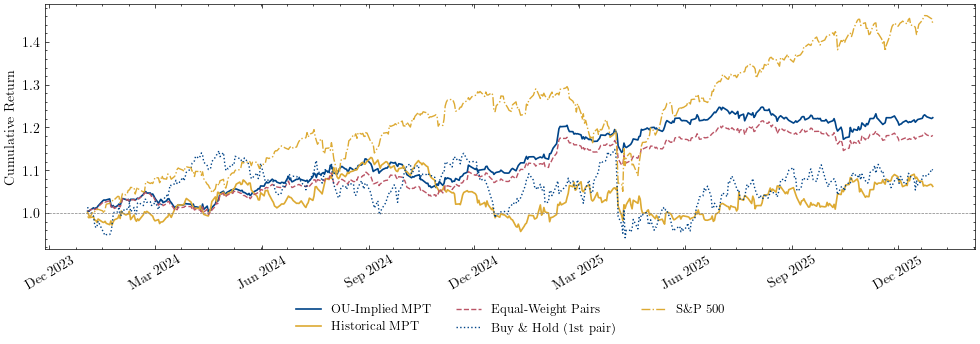

In [29]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cum_ou.index,   cum_ou.values,   linewidth=1.2, label="OU-Implied MPT")
ax.plot(cum_hist.index, cum_hist.values, linewidth=1.2, label="Historical MPT")
ax.plot(cum_eq.index,   cum_eq.values,   linewidth=1,   label="Equal-Weight Pairs", linestyle="--")
ax.plot(cum_bh.index,   cum_bh.values,   linewidth=1,   label=r"Buy \& Hold (1st pair)", linestyle=":")
ax.plot(cum_spy.index,  cum_spy.values,  linewidth=1,   label=r"S\&P 500", linestyle="-.")
ax.axhline(1.0, color="grey", linewidth=0.5, linestyle="--")
ax.set_ylabel("Cumulative Return")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.tick_params(axis="x", rotation=30)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=9)
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig("figures/04_cumulative_returns.pdf", bbox_inches="tight")
plt.show()

### Drawdown

Peak-to-trough drawdown over the OOS period. Lower (closer to zero) is better. The OU-Implied portfolio exhibits shallower drawdowns than the Historical MPT and S&P 500, reflecting the risk-reduction benefit of spread-based diversification.

In [30]:
def _drawdown(ret):
    cum = (1 + ret).cumprod()
    return cum / cum.cummax() - 1

dd_ou   = _drawdown(ou_portfolio_returns)
dd_hist = _drawdown(hist_portfolio_returns)
dd_spy  = _drawdown(benchmarks["sp500"])

fig_dd = go.Figure()
fig_dd.add_trace(go.Scatter(x=dd_ou.index, y=dd_ou.values, name="OU-Implied MPT",
                             fill="tozeroy", line=dict(color=COLORS[0])))
fig_dd.add_trace(go.Scatter(x=dd_hist.index, y=dd_hist.values, name="Historical MPT",
                             fill="tozeroy", line=dict(color=COLORS[1])))
fig_dd.add_trace(go.Scatter(x=dd_spy.index, y=dd_spy.values, name="S&P 500",
                             line=dict(color=COLORS[2], dash="dash")))
fig_dd.update_layout(
    title="Drawdown (OOS 2024-2025)",
    yaxis_title="Drawdown", yaxis_tickformat=".0%",
    xaxis_title="Date",
    legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="center", x=0.5),
    height=450,
)
fig_dd.show()

#### Save to Matplotlib

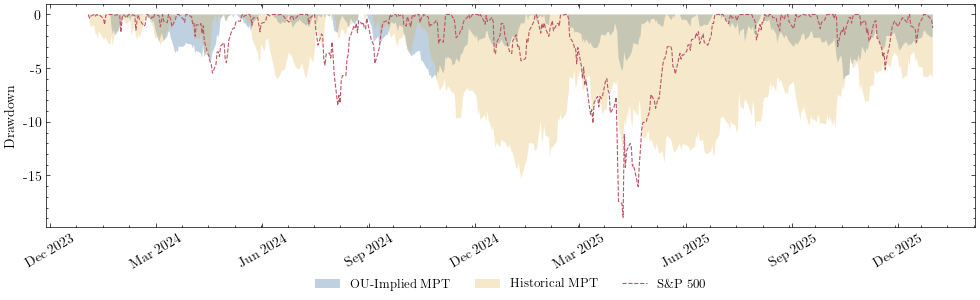

In [31]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.fill_between(dd_ou.index,   dd_ou.values,   alpha=0.25, label="OU-Implied MPT")
ax.fill_between(dd_hist.index, dd_hist.values, alpha=0.25, label="Historical MPT")
ax.plot(dd_spy.index, dd_spy.values, linewidth=0.8, linestyle="--", label=r"S\&P 500", color=COLORS[2])
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.tick_params(axis="x", rotation=30)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=9)
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig("figures/04_drawdown.pdf", bbox_inches="tight")
plt.show()

### Rolling 60-day Sharpe Ratio

Time-varying risk-adjusted performance computed over a trailing 60-day window. Periods where the OU-Implied portfolio's rolling Sharpe exceeds that of the Historical MPT indicate outperformance on a risk-adjusted basis.

In [32]:
def _rolling_sharpe(ret, window=ROLL, rf_annual=rf_annual_avg):
    rf_daily = rf_annual / 252
    excess = ret - rf_daily
    roll_mean = excess.rolling(window).mean()
    roll_std  = excess.rolling(window).std(ddof=1)
    return (roll_mean / roll_std) * np.sqrt(252)

rs_ou   = _rolling_sharpe(ou_portfolio_returns)
rs_hist = _rolling_sharpe(hist_portfolio_returns)
rs_spy  = _rolling_sharpe(benchmarks["sp500"])

fig_rs = go.Figure()
fig_rs.add_trace(go.Scatter(x=rs_ou.index, y=rs_ou.values, name="OU-Implied MPT",
                             line=dict(color=COLORS[0])))
fig_rs.add_trace(go.Scatter(x=rs_hist.index, y=rs_hist.values, name="Historical MPT",
                             line=dict(color=COLORS[1])))
fig_rs.add_trace(go.Scatter(x=rs_spy.index, y=rs_spy.values, name="S&P 500",
                             line=dict(color=COLORS[2], dash="dash")))
fig_rs.add_hline(y=0, line_color="grey", line_dash="dash", line_width=0.5)
fig_rs.update_layout(
    title=f"Rolling {ROLL}-day Sharpe Ratio (OOS 2024-2025)",
    yaxis_title=f"Rolling {ROLL}-day Sharpe",
    xaxis_title="Date",
    legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="center", x=0.5),
    height=450,
)
fig_rs.show()

#### Save to Matplotlib

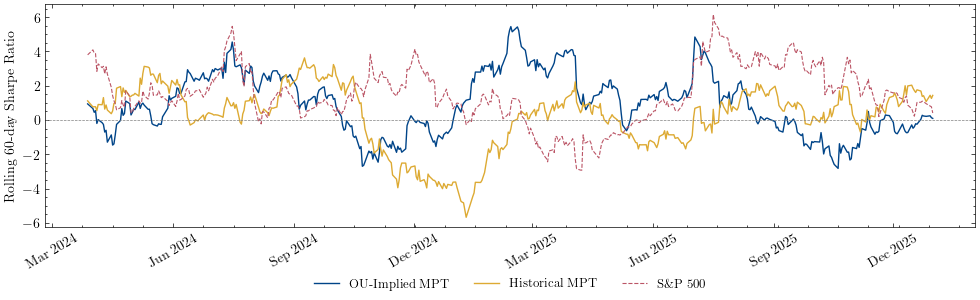

In [33]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(rs_ou.index,   rs_ou.values,   linewidth=1, label="OU-Implied MPT")
ax.plot(rs_hist.index, rs_hist.values, linewidth=1, label="Historical MPT")
ax.plot(rs_spy.index,  rs_spy.values,  linewidth=0.8, linestyle="--", label=r"S\&P 500", color=COLORS[2])
ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.set_ylabel(f"Rolling {ROLL}-day Sharpe Ratio")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.tick_params(axis="x", rotation=30)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=9)
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig("figures/04_rolling_sharpe.pdf", bbox_inches="tight")
plt.show()

### Portfolio Weights

Minimum-variance portfolio weights for both approaches. The OU-Implied MPT allocates across three cointegrated spreads; the Historical MPT allocates across the six underlying assets. The spread-space weights are more evenly distributed, reflecting the lower cross-correlation of spread returns.

In [34]:
spread_labels = [c.replace("_vs_", " / ") for c in spread_returns.columns]
asset_labels  = [TICKER_NAMES.get(t, t) for t in tickers]

fig_w = make_subplots(rows=1, cols=2, subplot_titles=["OU-Implied MPT (spread space)", "Historical MPT (asset space)"])
fig_w.add_trace(go.Bar(x=spread_labels, y=w_spread, marker_color=COLORS[0],
                        text=[f"{w:.2f}" for w in w_spread], textposition="outside"), row=1, col=1)
fig_w.add_trace(go.Bar(x=asset_labels, y=w_asset, marker_color=COLORS[1],
                        text=[f"{w:.2f}" for w in w_asset], textposition="outside"), row=1, col=2)
fig_w.update_yaxes(title_text="Weight", row=1, col=1)
fig_w.update_layout(height=400, showlegend=False)
fig_w.show()

#### Save to Matplotlib

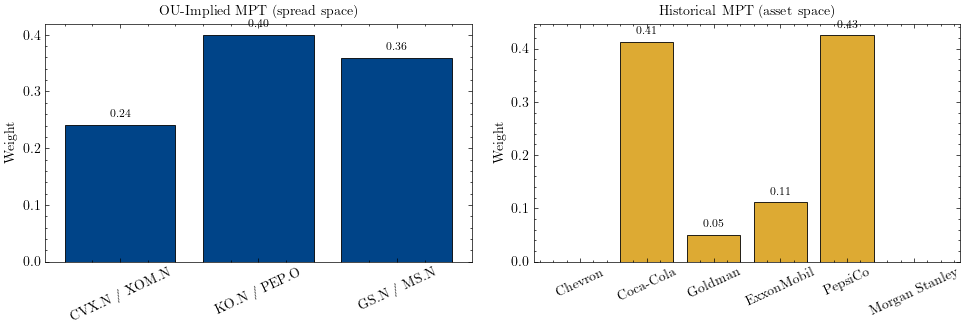

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

bars0 = axes[0].bar(spread_labels, w_spread, color=COLORS[0],
                    edgecolor="black", linewidth=0.6)
axes[0].set_title("OU-Implied MPT (spread space)", fontsize=10)
axes[0].set_ylabel("Weight")
axes[0].tick_params(axis="x", rotation=25)
for bar, w in zip(bars0, w_spread):
    if w > 0.02:
        axes[0].text(bar.get_x() + bar.get_width()/2, w + 0.01,
                     f"{w:.2f}", ha="center", va="bottom", fontsize=8)

bars1 = axes[1].bar(asset_labels, w_asset, color=COLORS[1],
                    edgecolor="black", linewidth=0.6)
axes[1].set_title("Historical MPT (asset space)", fontsize=10)
axes[1].set_ylabel("Weight")
axes[1].tick_params(axis="x", rotation=25)
for bar, w in zip(bars1, w_asset):
    if w > 0.02:
        axes[1].text(bar.get_x() + bar.get_width()/2, w + 0.01,
                     f"{w:.2f}", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
fig.savefig("figures/04_weights_bar.pdf", bbox_inches="tight")
plt.show()

### Per-Pair Cumulative Returns (Backtest Engine)

Cumulative returns from the z-score mean-reversion backtest engine for each cointegrated pair individually. Green-shaded regions indicate long-spread positions; red-shaded regions indicate short-spread positions.

In [36]:
fig_pc = make_subplots(rows=n_pairs, cols=1, shared_xaxes=True,
                       subplot_titles=[PAIR_LABELS[p] for p in pair_results])
for i, (pair_name, result) in enumerate(pair_results.items(), 1):
    cum = result.cumulative_returns
    fig_pc.add_trace(go.Scatter(x=cum.index, y=cum.values, name=PAIR_LABELS[pair_name],
                                line=dict(color=COLORS[i-1]), showlegend=False), row=i, col=1)
    fig_pc.update_yaxes(title_text="Cumulative Return", row=i, col=1)
fig_pc.add_hline(y=1.0, line_color="grey", line_dash="dash", line_width=0.5)
fig_pc.update_layout(height=300 * n_pairs, title="Per-Pair Cumulative Returns (Backtest Engine)")
fig_pc.show()

#### Save to Matplotlib

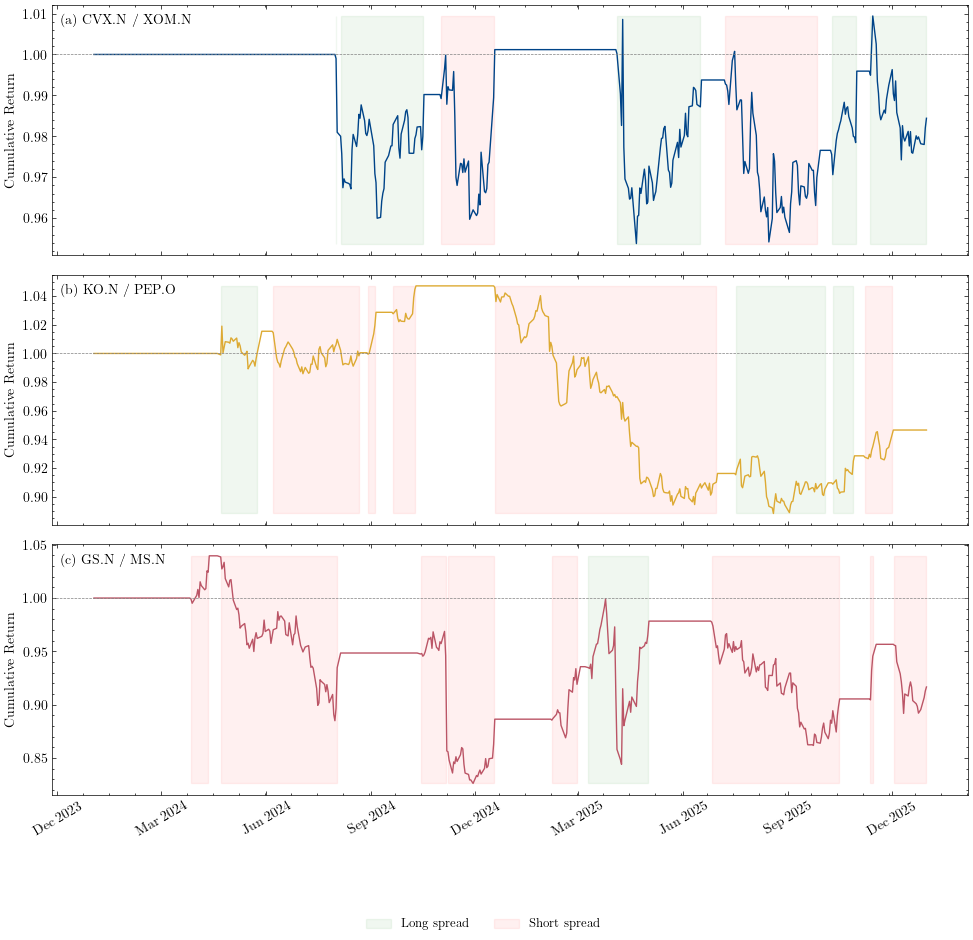

In [37]:
fig, axes = plt.subplots(nrows=n_pairs, ncols=1, figsize=(10, 3 * n_pairs), sharex=True)
if n_pairs == 1:
    axes = [axes]

for i, (pair_name, result) in enumerate(pair_results.items()):
    ax = axes[i]
    cum = result.cumulative_returns
    ax.plot(cum.index, cum.values, linewidth=1, color=COLORS[i])
    ax.axhline(1.0, color="grey", linewidth=0.5, linestyle="--")

    pos = result.positions["position"]
    long_mask  = pos == 1.0
    short_mask = pos == -1.0
    ax.fill_between(cum.index, cum.min(), cum.max(),
                    where=long_mask, alpha=0.06, color="green", label="Long spread")
    ax.fill_between(cum.index, cum.min(), cum.max(),
                    where=short_mask, alpha=0.06, color="red", label="Short spread")

    ax.text(0.01, 0.92, f"{panel_labels[i]} {PAIR_LABELS[pair_name]}",
            transform=ax.transAxes, fontsize=10, fontweight="bold")
    ax.set_ylabel("Cumulative Return")

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].tick_params(axis="x", rotation=30)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=9)
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig("figures/04_pair_cumulative_returns.pdf", bbox_inches="tight")
plt.show()

### Per-Pair Z-Scores with Trading Thresholds

Rolling z-scores for each cointegrated spread with entry ($\pm 2.0$) and stop-loss ($\pm 4.0$) thresholds. Trades are triggered when the z-score crosses the entry threshold and closed when it reverts to zero or breaches the stop-loss.

In [38]:
fig_z = make_subplots(rows=n_pairs, cols=1, shared_xaxes=True,
                      subplot_titles=[PAIR_LABELS[p] for p in pair_results])
for i, (pair_name, result) in enumerate(pair_results.items(), 1):
    z = result.zscore.dropna()
    fig_z.add_trace(go.Scatter(x=z.index, y=z.values, name=PAIR_LABELS[pair_name],
                               line=dict(color=COLORS[i-1]), showlegend=False), row=i, col=1)
    for thresh, color, dash in [
        (config.entry_z, "grey", "dash"), (-config.entry_z, "grey", "dash"),
        (config.stop_loss_z, "red", "dot"), (-config.stop_loss_z, "red", "dot"),
    ]:
        fig_z.add_hline(y=thresh, line_color=color, line_dash=dash, line_width=0.8, row=i, col=1)
    fig_z.update_yaxes(title_text="Z-Score", row=i, col=1)
fig_z.update_layout(height=300 * n_pairs, title="Per-Pair Z-Scores with Trading Thresholds")
fig_z.show()

#### Save to Matplotlib

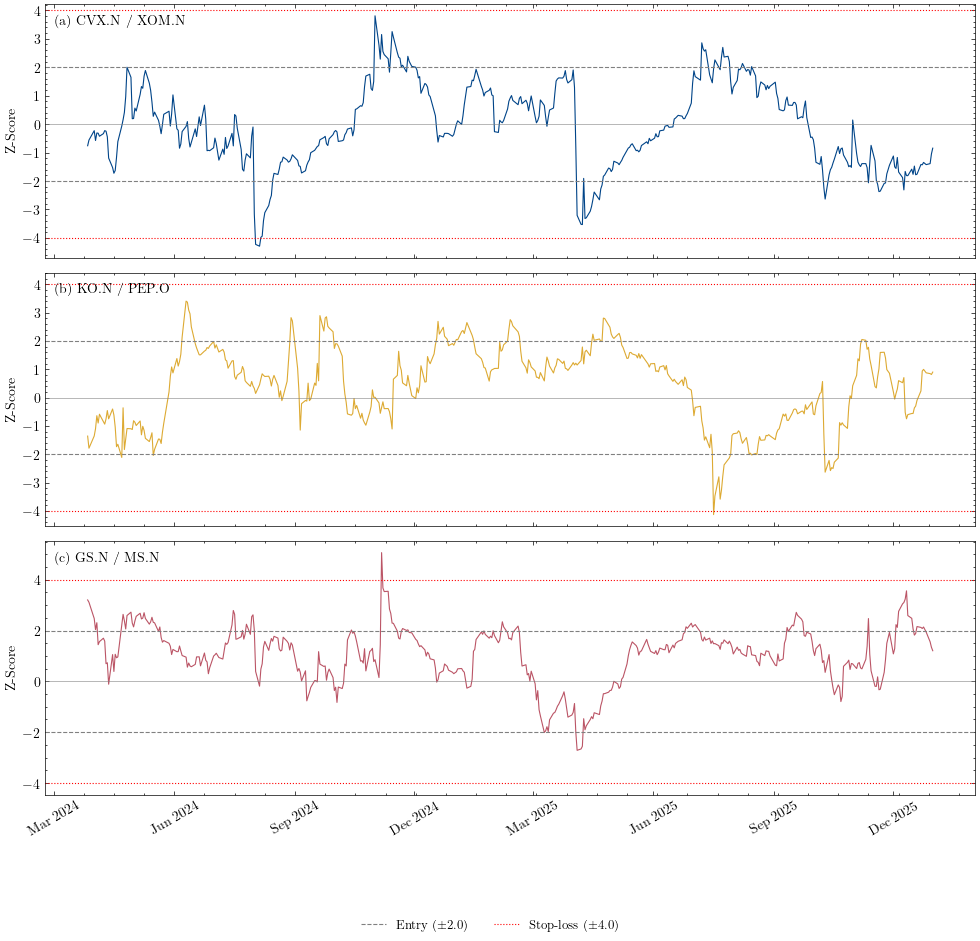

In [39]:
fig, axes = plt.subplots(nrows=n_pairs, ncols=1, figsize=(10, 3 * n_pairs), sharex=True)
if n_pairs == 1:
    axes = [axes]

for i, (pair_name, result) in enumerate(pair_results.items()):
    ax = axes[i]
    z = result.zscore.dropna()
    ax.plot(z.index, z.values, linewidth=0.8, color=COLORS[i])
    ax.axhline(+config.entry_z, color="grey", linewidth=0.8, linestyle="--", label=f"Entry ($\\pm${config.entry_z})")
    ax.axhline(-config.entry_z, color="grey", linewidth=0.8, linestyle="--")
    ax.axhline(+config.stop_loss_z, color="red", linewidth=0.8, linestyle=":", label=f"Stop-loss ($\\pm${config.stop_loss_z})")
    ax.axhline(-config.stop_loss_z, color="red", linewidth=0.8, linestyle=":")
    ax.axhline(0, color="grey", linewidth=0.4)
    ax.text(0.01, 0.92, f"{panel_labels[i]} {PAIR_LABELS[pair_name]}",
            transform=ax.transAxes, fontsize=10, fontweight="bold")
    ax.set_ylabel("Z-Score")

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].tick_params(axis="x", rotation=30)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=9)
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig("figures/04_pair_zscores.pdf", bbox_inches="tight")
plt.show()

### Efficient Frontier

Mean-variance efficient frontiers for both the OU-Implied (spread space) and Historical (asset space) formulations. Stars mark the selected minimum-variance portfolios. The OU-Implied frontier operates in a lower-volatility region due to the mean-reverting nature of cointegrated spreads.

In [40]:
ef_spread = efficient_frontier(
    spread_returns,
    expected_returns=spread_mu.values / 252,
    cov_matrix=spread_cov.values / 252,
    rf_annual=rf_annual_avg, n_points=80,
)
ef_asset = efficient_frontier(
    asset_returns_oos,
    expected_returns=asset_mu.reindex(tickers).values / 252,
    cov_matrix=asset_cov.reindex(index=tickers, columns=tickers).values / 252,
    rf_annual=rf_annual_avg, n_points=80,
)

fig_ef = go.Figure()
fig_ef.add_trace(go.Scatter(x=ef_spread["volatility"], y=ef_spread["return"],
                             mode="lines", name="OU-Implied (spread space)",
                             line=dict(color=COLORS[0])))
fig_ef.add_trace(go.Scatter(x=ef_asset["volatility"], y=ef_asset["return"],
                             mode="lines", name="Historical (asset space)",
                             line=dict(color=COLORS[1])))
fig_ef.add_trace(go.Scatter(x=[spread_result["min_var_vol"]], y=[spread_result["min_var_return"]],
                             mode="markers", marker=dict(symbol="star", size=14, color=COLORS[0]),
                             name="OU Min-Var"))
fig_ef.add_trace(go.Scatter(x=[asset_result["min_var_vol"]], y=[asset_result["min_var_return"]],
                             mode="markers", marker=dict(symbol="star", size=14, color=COLORS[1]),
                             name="Hist Min-Var"))
fig_ef.update_layout(
    title="Efficient Frontiers",
    xaxis_title="Annualised Volatility", xaxis_tickformat=".0%",
    yaxis_title="Annualised Return", yaxis_tickformat=".0%",
    height=500,
)
fig_ef.show()

#### Save to Matplotlib

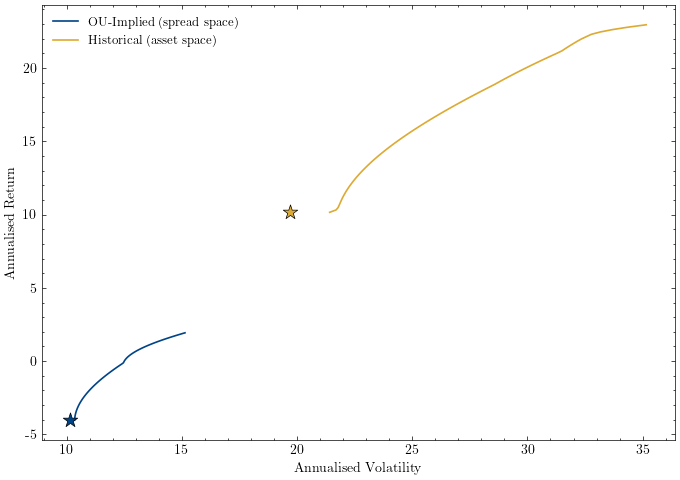

In [41]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ef_spread["volatility"], ef_spread["return"],
        linewidth=1.2, label="OU-Implied (spread space)")
ax.plot(ef_asset["volatility"], ef_asset["return"],
        linewidth=1.2, label="Historical (asset space)")
ax.scatter(spread_result["min_var_vol"], spread_result["min_var_return"],
           marker="*", s=120, zorder=5, color=COLORS[0], edgecolors="black", linewidths=0.5)
ax.scatter(asset_result["min_var_vol"], asset_result["min_var_return"],
           marker="*", s=120, zorder=5, color=COLORS[1], edgecolors="black", linewidths=0.5)
ax.set_xlabel("Annualised Volatility")
ax.set_ylabel("Annualised Return")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("figures/04_efficient_frontier.pdf", bbox_inches="tight")
plt.show()

### Rolling 60-day Annualised Volatility

Time-varying portfolio risk measured by trailing 60-day annualised standard deviation. The OU-Implied portfolio maintains consistently lower volatility than both the Historical MPT and S&P 500 throughout the test period.

In [42]:
rv_ou   = ou_portfolio_returns.rolling(ROLL).std(ddof=1) * np.sqrt(252)
rv_hist = hist_portfolio_returns.rolling(ROLL).std(ddof=1) * np.sqrt(252)
rv_spy  = benchmarks["sp500"].rolling(ROLL).std(ddof=1) * np.sqrt(252)

fig_rv = go.Figure()
fig_rv.add_trace(go.Scatter(x=rv_ou.index, y=rv_ou.values, name="OU-Implied MPT",
                             line=dict(color=COLORS[0])))
fig_rv.add_trace(go.Scatter(x=rv_hist.index, y=rv_hist.values, name="Historical MPT",
                             line=dict(color=COLORS[1])))
fig_rv.add_trace(go.Scatter(x=rv_spy.index, y=rv_spy.values, name="S&P 500",
                             line=dict(color=COLORS[2], dash="dash")))
fig_rv.update_layout(
    title=f"Rolling {ROLL}-day Annualised Volatility (OOS 2024-2025)",
    yaxis_title="Ann. Volatility", yaxis_tickformat=".0%",
    xaxis_title="Date",
    legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="center", x=0.5),
    height=450,
)
fig_rv.show()

#### Save to Matplotlib

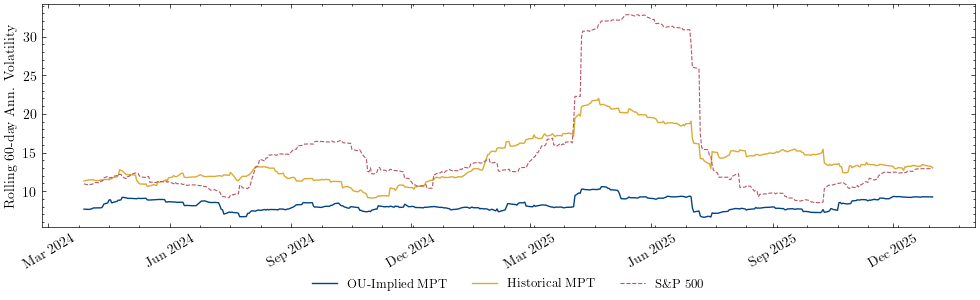

In [43]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(rv_ou.index,   rv_ou.values,   linewidth=1, label="OU-Implied MPT")
ax.plot(rv_hist.index, rv_hist.values, linewidth=1, label="Historical MPT")
ax.plot(rv_spy.index,  rv_spy.values,  linewidth=0.8, linestyle="--", label=r"S\&P 500", color=COLORS[2])
ax.set_ylabel(f"Rolling {ROLL}-day Ann. Volatility")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.tick_params(axis="x", rotation=30)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=9)
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig("figures/04_rolling_volatility.pdf", bbox_inches="tight")
plt.show()

### Return Distribution

Histogram of daily portfolio returns for the OU-Implied and Historical MPT portfolios. The OU-Implied distribution is tighter (lower variance) and centred around a slightly higher mean, consistent with the superior Sharpe ratio observed in the metrics table.

In [44]:
fig_hist = go.Figure()
fig_hist.add_trace(go.Histogram(x=ou_portfolio_returns.dropna(), name="OU-Implied MPT",
                                 opacity=0.7, nbinsx=50, marker_color=COLORS[0]))
fig_hist.add_trace(go.Histogram(x=hist_portfolio_returns.dropna(), name="Historical MPT",
                                 opacity=0.7, nbinsx=50, marker_color=COLORS[1]))
fig_hist.update_layout(
    barmode="overlay",
    title="Daily Return Distribution (OOS 2024-2025)",
    xaxis_title="Daily Return", yaxis_title="Count",
    legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="center", x=0.5),
    height=450,
)
fig_hist.show()

#### Save to Matplotlib

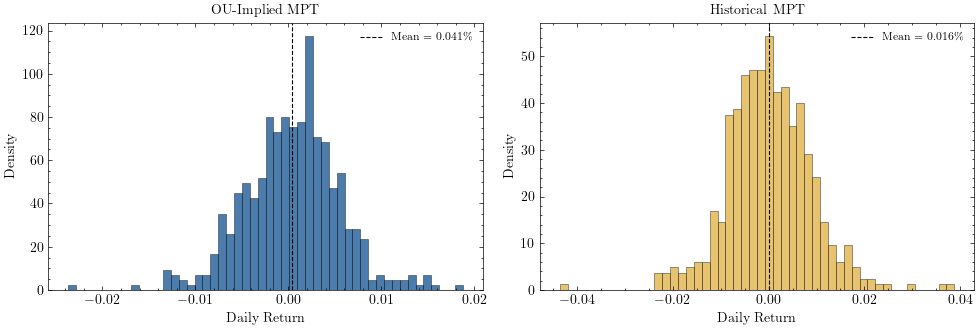

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax, ret, name, col in [
    (axes[0], ou_portfolio_returns, "OU-Implied MPT", COLORS[0]),
    (axes[1], hist_portfolio_returns, "Historical MPT", COLORS[1]),
]:
    ax.hist(ret.dropna(), bins=50, color=col, edgecolor="black",
            linewidth=0.4, alpha=0.7, density=True)
    ax.axvline(ret.mean(), color="black", linewidth=0.8, linestyle="--",
               label=f"Mean = {ret.mean()*100:.3f}\\%")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Daily Return")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig("figures/04_return_distribution.pdf", bbox_inches="tight")
plt.show()